## Task 1

### Load  and First Inspection of the Dataset

In [1]:
import pandas as pd

# This tells pandas not to wrap the table into multiple chunks
pd.set_option('display.expand_frame_repr', False)

df = df = pd.read_csv('metraq_air_quality.csv',
                 dtype={
                     'sensor_id': 'int32',
                     'magnitude_id': 'int16',
                     'value': 'float64',
                     'is_interpolated': 'bool'
                 })

print(f"First 5 rows:\n{df.head()}\n")

print(f"DataFrame Info:")
df.info()
print()

print(f"\nMissing Values:\n{df.isnull().sum()}")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}\n")

print(f"DataFrame Description:\n{df.describe()}")

First 5 rows:
   sensor_id      sensor_name        utm_x        utm_y  magnitude_id magnitude_name           entry_date  value  is_interpolated
0   28079004  Plaza de España  439579.3291  4475049.263             1            SO2  2001-01-01 00:00:00   21.0            False
1   28079004  Plaza de España  439579.3291  4475049.263             6             CO  2001-01-01 00:00:00    1.0            False
2   28079004  Plaza de España  439579.3291  4475049.263             7             NO  2001-01-01 00:00:00   83.0            False
3   28079004  Plaza de España  439579.3291  4475049.263             8            NO2  2001-01-01 00:00:00   50.0            False
4   28079004  Plaza de España  439579.3291  4475049.263            12            NOX  2001-01-01 00:00:00  177.0            False

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64881744 entries, 0 to 64881743
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   sensor_id 

### Inspecting Categorical Columns

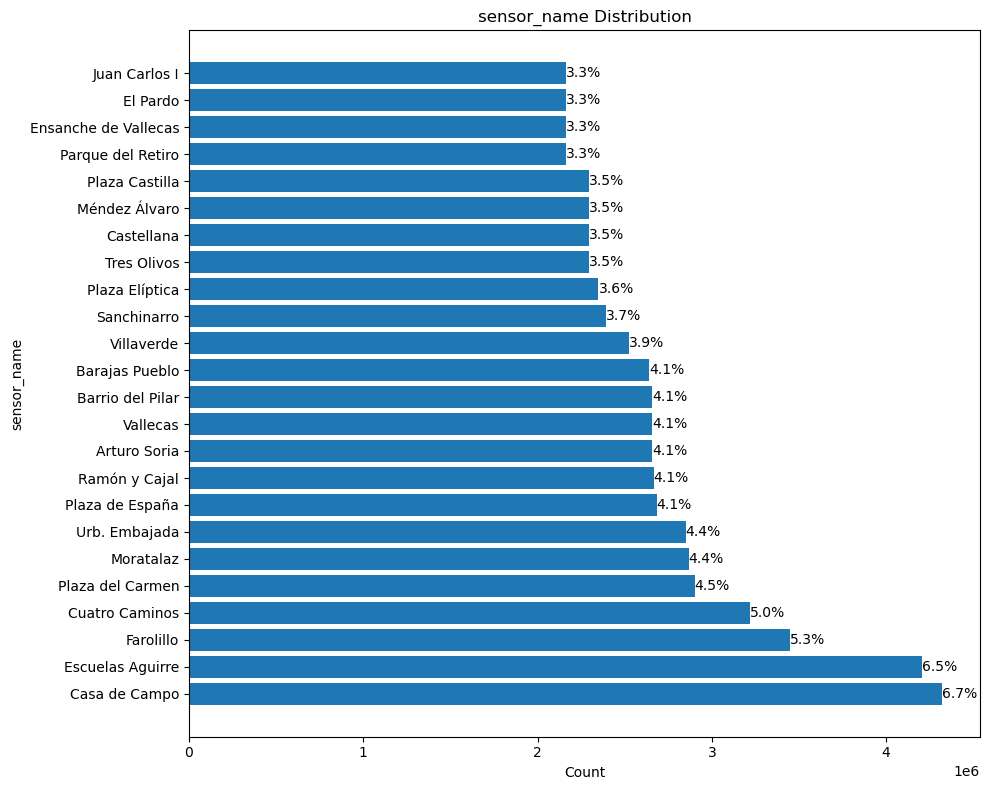

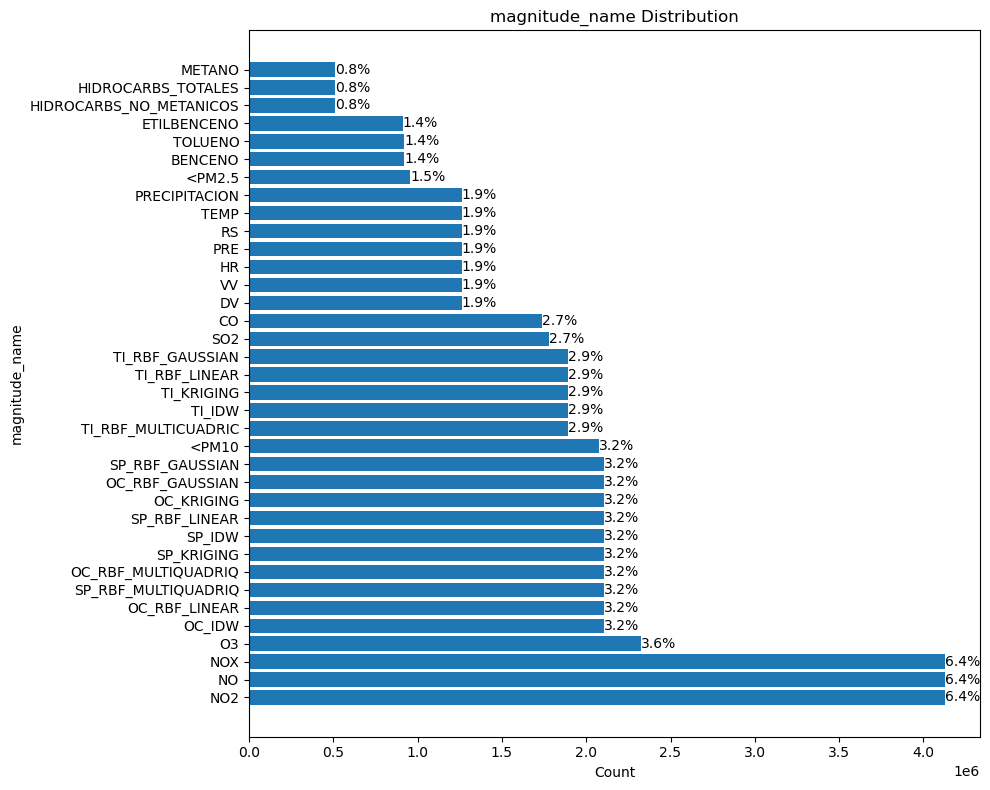

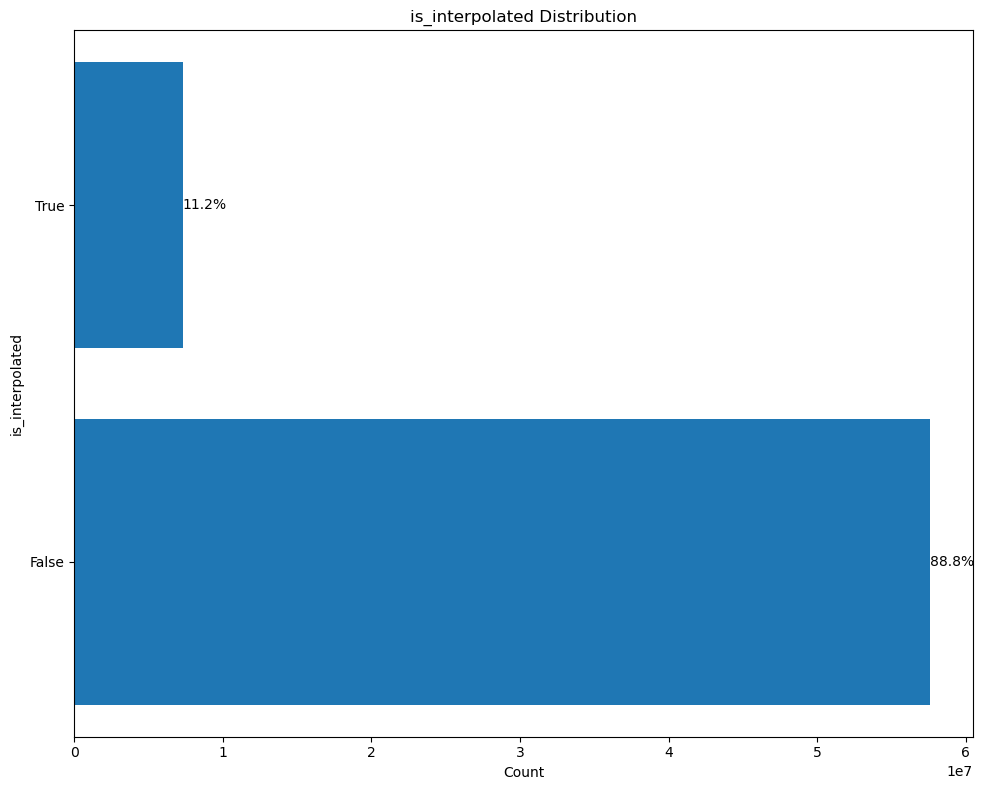

In [2]:
import matplotlib.pyplot as plt

def plot_categorical_distribution_horizontal(df, column, top_n=None, figsize=(10, 8)):
    # Count values (including NaN)
    counts = df[column].value_counts(dropna=False)
    
    # Optionally limit to top N categories
    if top_n:
        counts = counts.head(top_n)
    
    # Convert labels to string (so NaN shows as "nan")
    labels = counts.index.astype(str)
    values = counts.values
    total = values.sum()
    
    # Create horizontal bar chart
    plt.figure(figsize=figsize)
    bars = plt.barh(labels, values)
    
    # Add percentage labels
    for bar, value in zip(bars, values):
        percentage = (value / total) * 100
        plt.text(
            bar.get_width(),                      # x position
            bar.get_y() + bar.get_height() / 2,   # y position
            f"{percentage:.1f}%",
            va='center'
        )
    
    # Labels and title
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.title(f"{column} Distribution")
    
    plt.tight_layout()
    plt.show()

plot_categorical_distribution_horizontal(df, "sensor_name")
plot_categorical_distribution_horizontal(df, "magnitude_name")
plot_categorical_distribution_horizontal(df, "is_interpolated")

### Exploring Numerical Columns

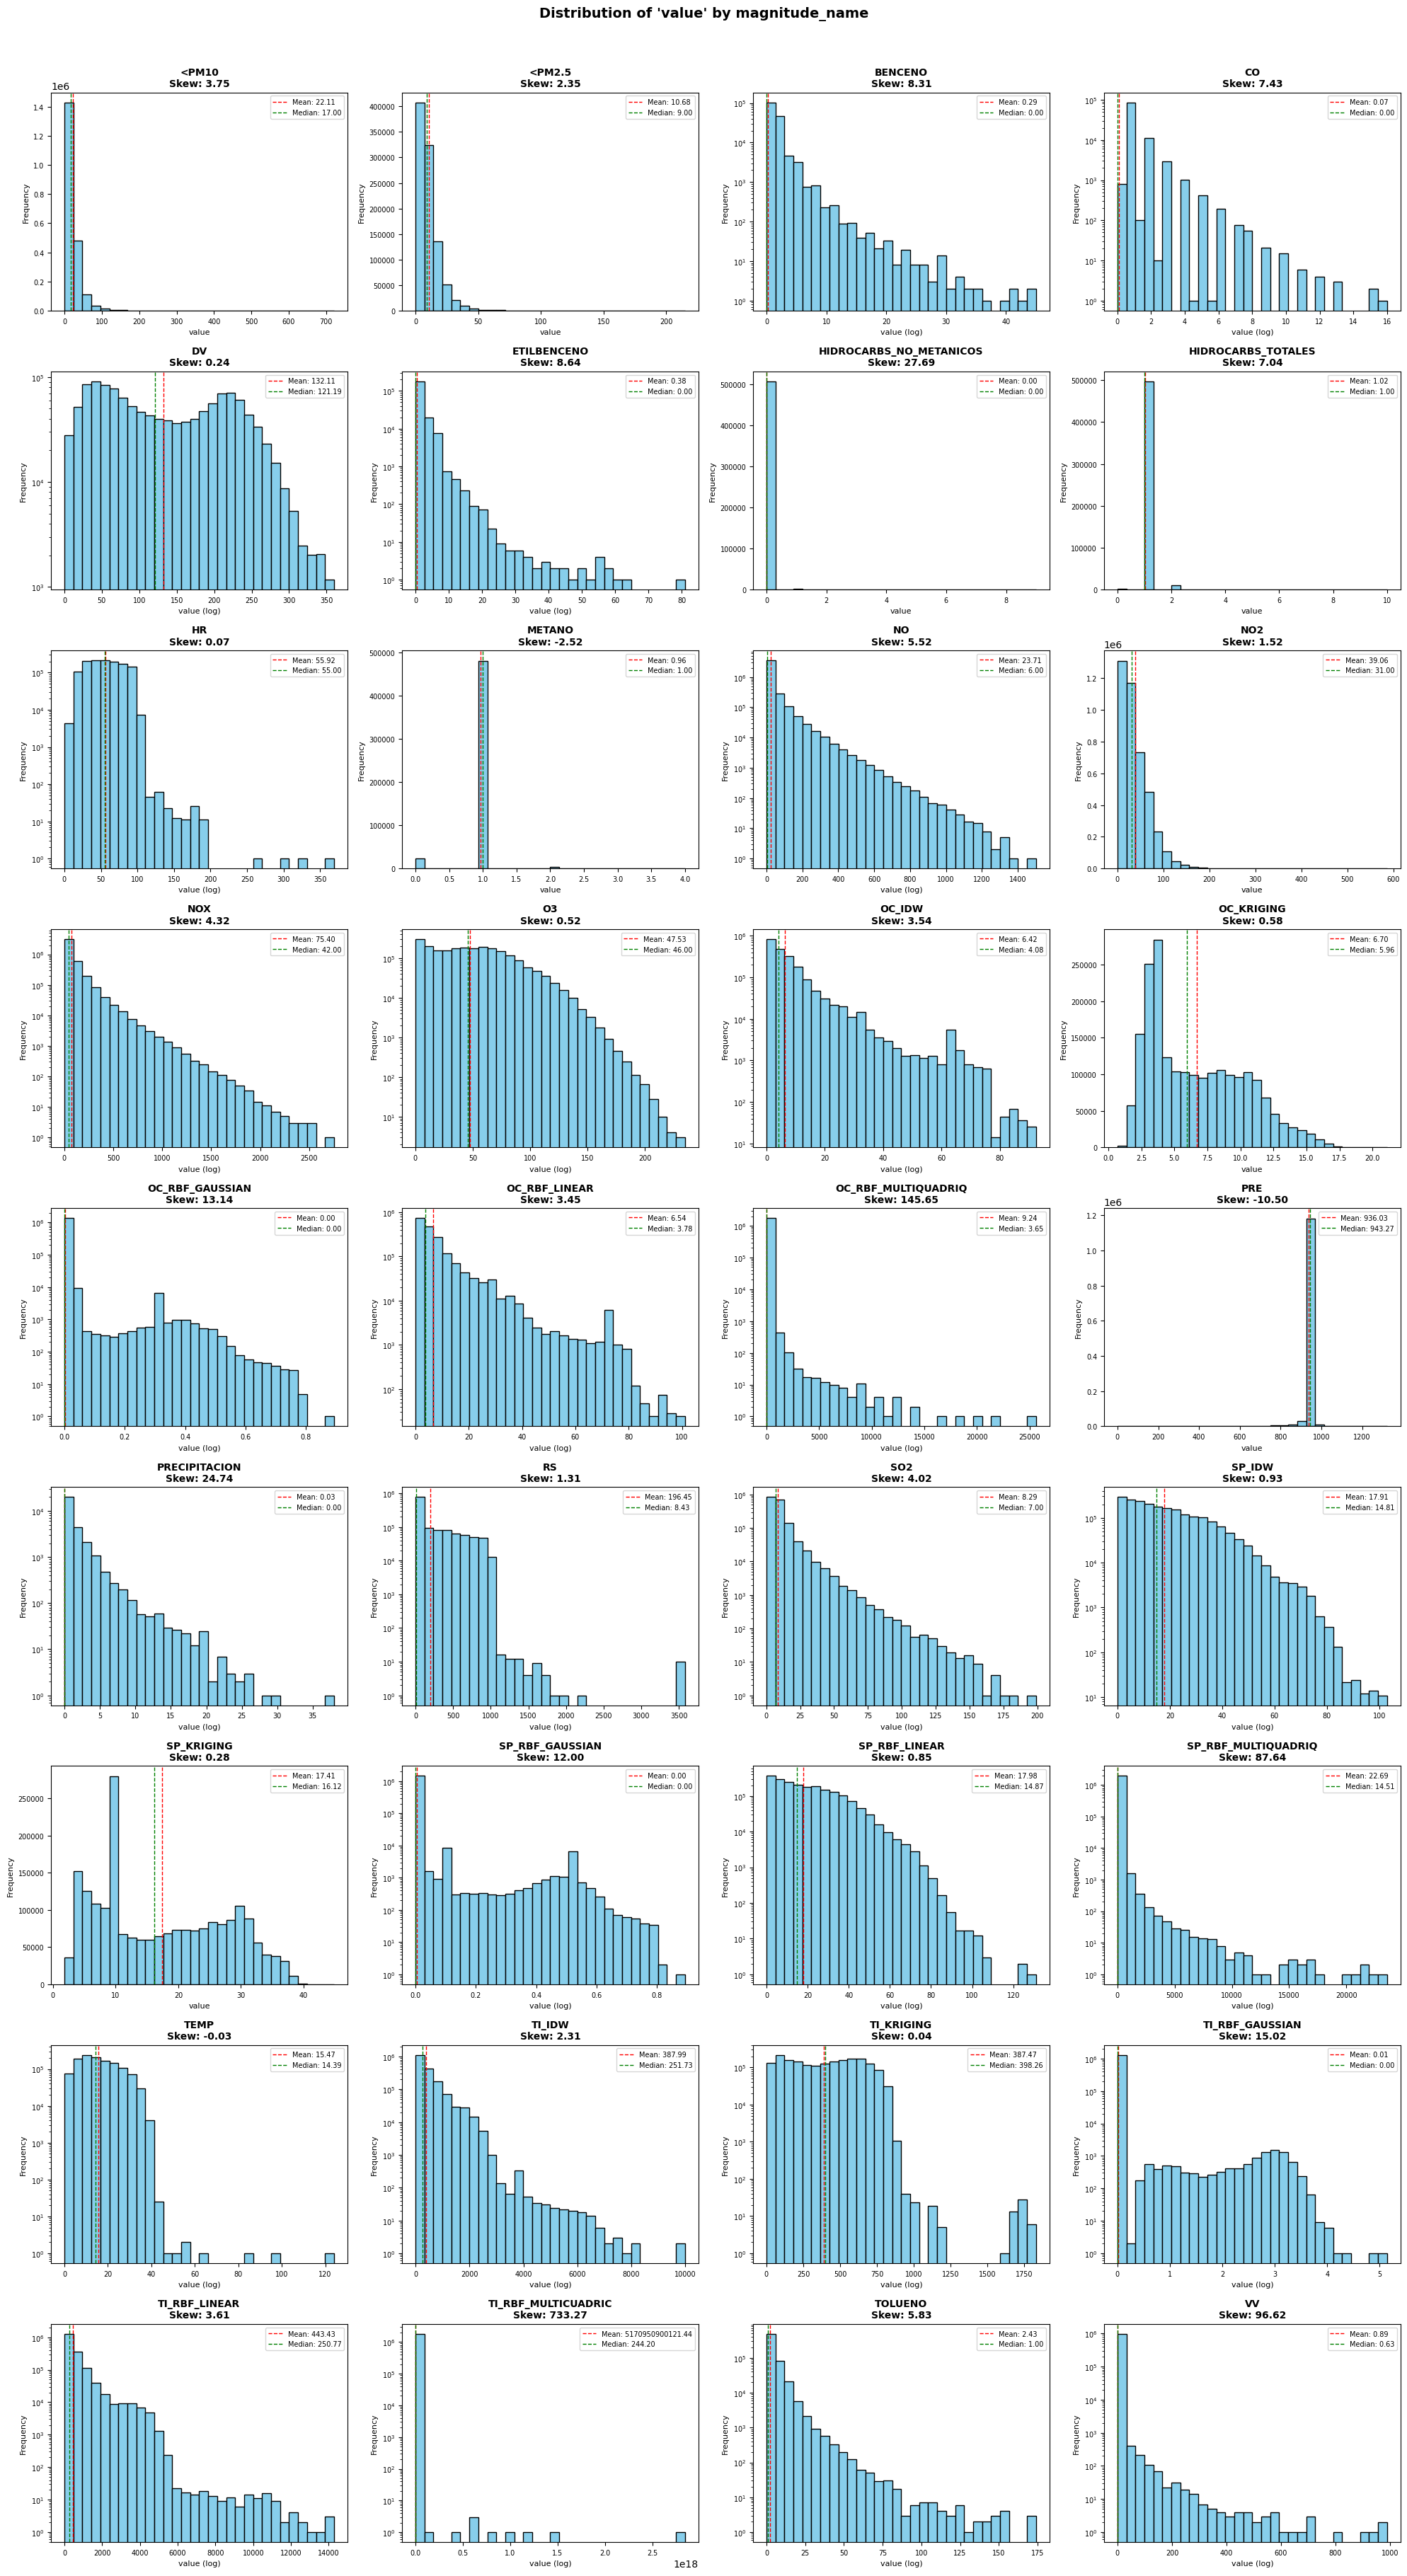

In [3]:
from scipy.stats import skew
import matplotlib.pyplot as plt
import math
import numpy as np

def plot_numeric_distributions(data, value_column, group_column="magnitude_name", bins=30):
    groups = sorted(data[group_column].dropna().unique())
    n_cols = 4
    n_rows = math.ceil(len(groups) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()

    for i, group in enumerate(groups):
        ax = axes[i]
        col = data.loc[data[group_column] == group, value_column].dropna()

        if len(col) < 2 or col.nunique() < 2:
            ax.set_title(f"{group}\n(insufficient data)", fontsize=9)
            ax.set_visible(True)
            continue

        mean_val   = col.mean()
        median_val = col.median()
        skewness   = skew(col)

        # Fix: safely determine if log scale is appropriate
        col_positive = col[col > 0]
        use_log = False
        if len(col_positive) > 1:
            min_pos = col_positive.min()
            max_pos = col_positive.max()
            # Avoid division by zero or log(1) edge case
            if min_pos > 0 and max_pos > min_pos:
                use_log = (np.log10(max_pos) - np.log10(min_pos)) > 3

        plot_data = col_positive if use_log else col

        ax.hist(plot_data, bins=bins, color="skyblue", edgecolor="black", log=use_log)
        ax.set_title(f"{group}\nSkew: {skewness:.2f}", fontsize=10, fontweight="bold")
        ax.set_xlabel(f"{value_column}{' (log)' if use_log else ''}", fontsize=8)
        ax.set_ylabel("Frequency", fontsize=8)
        ax.axvline(mean_val,   color="red",   linestyle="--", linewidth=1, label=f"Mean: {mean_val:.2f}")
        ax.axvline(median_val, color="green", linestyle="--", linewidth=1, label=f"Median: {median_val:.2f}")
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    # Hide all truly unused subplots
    for j in range(len(groups), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distribution of '{value_column}' by {group_column}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_numeric_distributions(df, "value", group_column="magnitude_name")

### Timeline

In [4]:
print(df["entry_date"].unique()[:20])
print(df["entry_date"].dtype)

# See which rows don't match the expected format
mask = ~df["entry_date"].str.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$')
print(df[mask]["entry_date"].value_counts())
print(f"Total problematic rows: {mask.sum()}")

# Drop rows with invalid entry_date format
df = df[~mask]

['2001-01-01 00:00:00' '2001-01-01 01:00:00' '2001-01-01 02:00:00'
 '2001-01-01 03:00:00' '2001-01-01 04:00:00' '2001-01-01 05:00:00'
 '2001-01-01 06:00:00' '2001-01-01 07:00:00' '2001-01-01 08:00:00'
 '2001-01-01 09:00:00' '2001-01-01 10:00:00' '2001-01-01 11:00:00'
 '2001-01-01 12:00:00' '2001-01-01 13:00:00' '2001-01-01 14:00:00'
 '2001-01-01 15:00:00' '2001-01-01 16:00:00' '2001-01-01 17:00:00'
 '2001-01-01 18:00:00' '2001-01-01 19:00:00']
object
entry_date
2015-05-11    1
2015-01-26    1
2015-10-28    1
2017-04-24    1
2017-11-28    1
2019-06-23    1
2020-09-02    1
2021-03-14    1
2021-06-27    1
2022-11-06    1
2022-12-06    1
2024-06-23    1
2024-02-09    1
Name: count, dtype: int64
Total problematic rows: 13


--- Timeline Details ---
Start Date: 2001-01-01 00:00:00
End Date:   2024-12-31 23:00:00
Duration:   23 years, 11 months, 30 days (Total: 8765 days)
------------------------


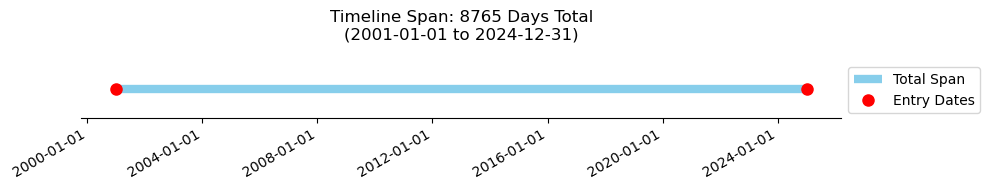

In [5]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.dates as mdates

def plot_timeline_span(date_strings):
    """
    Takes a list of datetime strings, calculates the span, 
    and plots a 1D timeline showing the entries and total duration.
    """
    # 1. Convert string dates to datetime objects
    date_format = "%Y-%m-%d %H:%M:%S"
    dates = [datetime.strptime(date_str, date_format) for date_str in date_strings]
    
    # 2. Find the span (min and max dates)
    start_date = min(dates)
    end_date = max(dates)
    
    # 3. Calculate the duration
    delta = relativedelta(end_date, start_date)
    total_days = (end_date - start_date).days
    
    print(f"--- Timeline Details ---")
    print(f"Start Date: {start_date}")
    print(f"End Date:   {end_date}")
    print(f"Duration:   {delta.years} years, {delta.months} months, {delta.days} days (Total: {total_days} days)")
    print(f"------------------------")

    # 4. Create the plot
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # Plot the full span as a horizontal line
    ax.hlines(y=0, xmin=start_date, xmax=end_date, color='skyblue', linewidth=6, label='Total Span')
    
    # Plot the individual dates as points
    ax.plot(dates, [0] * len(dates), "ro", markersize=8, label="Entry Dates")
    
    # Format the axes
    ax.get_yaxis().set_visible(False) # Hide y-axis as it's a 1D timeline
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Format the x-axis dates nicely
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate() # Rotate dates so they don't overlap
    
    # Add titles and legend
    plt.title(f"Timeline Span: {total_days} Days Total\n({start_date.date()} to {end_date.date()})", pad=15)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

    
plot_timeline_span([df["entry_date"].min(), df["entry_date"].max()])

### Mapping pollutants, weather, and traffic variables

In [6]:
pollutants = ['SO2', 'CO', 'NO', 'NO2', 'NOX', 'O3', '<PM2.5', '<PM10', 
              'BENCENO', 'TOLUENO', 'ETILBENCENO', 'METANO', 
              'HIDROCARBS_TOTALES', 'HIDROCARBS_NO_METANICOS']
meteorological = ['VV', 'DV', 'TEMP', 'HR', 'PRE', 'RS', 'PRECIPITACION']
traffic = [m for m in df['magnitude_name'].unique() if m.startswith(('TI_', 'SP_', 'OC_'))]

def categorize_magnitude(name):
    if name in pollutants:
        return 'pollutant'
    elif name in meteorological:
        return 'meteorological'
    elif name in traffic:
        return 'traffic'
    else:
        return 'unknown'

df['category'] = df['magnitude_name'].map(categorize_magnitude)

print(print(df.head(10)))

   sensor_id      sensor_name        utm_x        utm_y  magnitude_id magnitude_name           entry_date  value  is_interpolated   category
0   28079004  Plaza de España  439579.3291  4475049.263             1            SO2  2001-01-01 00:00:00   21.0            False  pollutant
1   28079004  Plaza de España  439579.3291  4475049.263             6             CO  2001-01-01 00:00:00    1.0            False  pollutant
2   28079004  Plaza de España  439579.3291  4475049.263             7             NO  2001-01-01 00:00:00   83.0            False  pollutant
3   28079004  Plaza de España  439579.3291  4475049.263             8            NO2  2001-01-01 00:00:00   50.0            False  pollutant
4   28079004  Plaza de España  439579.3291  4475049.263            12            NOX  2001-01-01 00:00:00  177.0            False  pollutant
5   28079004  Plaza de España  439579.3291  4475049.263             1            SO2  2001-01-01 01:00:00   23.0            False  pollutant
6   28079004 

/tmp/ipykernel_361723/2942620065.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['magnitude_name'].map(categorize_magnitude)


## Task 2

In [7]:
def check_value_validity(df, group_column='magnitude_name'):
    results = []
    
    for magnitude in sorted(df[group_column].unique()):
        # Filter to real measurements only, no copy needed
        col = df[(df[group_column] == magnitude) & 
                 (df['is_interpolated'] == False)]['value'].dropna()
        
        if len(col) < 4:
            continue
            
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        
        n_below = (col < lower).sum()
        n_above = (col > upper).sum()
        n_total = len(col)
        
        results.append({
            'magnitude': magnitude,
            'min': col.min(),
            'max': col.max(),
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'n_below_bound': n_below,
            'n_above_bound': n_above,
            'pct_outliers': round((n_below + n_above) / n_total * 100, 4)
        })
    
    return pd.DataFrame(results).set_index('magnitude')

validity = check_value_validity(df)
print(validity.to_string())

                                min           max          Q1            Q3   lower_bound   upper_bound  n_below_bound  n_above_bound  pct_outliers
magnitude                                                                                                                                          
<PM10                      0.000000  7.210000e+02    9.000000  2.800000e+01 -4.800000e+01  8.500000e+01              0          32256        1.5983
<PM2.5                     0.000000  2.150000e+02    5.000000  1.400000e+01 -2.200000e+01  4.100000e+01              0           9508        1.0304
BENCENO                    0.000000  4.500000e+01    0.000000  0.000000e+00  0.000000e+00  0.000000e+00              0         147614       16.8969
CO                         0.000000  1.600000e+01    0.000000  0.000000e+00  0.000000e+00  0.000000e+00              0         101472        5.9685
DV                         0.000000  3.600000e+02   42.000000  2.150000e+02 -4.770000e+02  7.340000e+02         

Looking at this table, there are several distinct issues.

**1. Physically impossible values (clear corruption)**
```
TEMP:  min = -318°C  (absolute zero is -273°C, impossible)
HR:    min = -149%   (humidity can't be negative)
HR:    max = 369%    (humidity can't exceed 100%)
PRE:   min = 0       (atmospheric pressure can't be 0)
PRE:   max = 1322    (normal range is ~870-1085 hPa)
TI_RBF_MULTICUADRIC: max = 2.85e18  (already identified)
```

**2. Gaussian RBF magnitudes behaving strangely**
```
OC_RBF_GAUSSIAN:  Q1=0, Q3=2.79e-24  → ~24% outliers
SP_RBF_GAUSSIAN:  Q1=0, Q3=2.17e-23  → ~24% outliers
TI_RBF_GAUSSIAN:  Q1=0, Q3=2.21e-23  → ~24% outliers
```
These have Q3 values of essentially zero (10⁻²³) which means the IQR is near-zero, so the outlier detection is not meaningful here — it's a numerical precision issue with the Gaussian interpolation method itself, not corruption.

**3. High outlier % but physically plausible**
```
BENCENO, ETILBENCENO, CO, TOLUENO  → 5-22% "outliers"
```
These are pollutants that are normally zero but spike during traffic/industrial events. Not corruption — just naturally sparse with occasional high readings.


#### Setting to NaN the physically impossible ones

In [8]:
# Physically impossible values → set to NaN
conditions = [
    (df['magnitude_name'] == 'TEMP') & (df['value'] < -273),
    (df['magnitude_name'] == 'HR') & ((df['value'] < 0) | (df['value'] > 100)),
    (df['magnitude_name'] == 'PRE') & ((df['value'] == 0) | (df['value'] > 1085)),
    (df['magnitude_name'] == 'TI_RBF_MULTICUADRIC') & (df['value'] > 1e15)
]

for condition in conditions:
    n = condition.sum()
    print(f"Setting {n} values to NaN")
    df.loc[condition, 'value'] = np.nan

# Quick sanity check after setting values to NaN
print(df[df['magnitude_name'] == 'TEMP']['value'].describe())
print(df[df['magnitude_name'] == 'HR']['value'].describe())
print(df[df['magnitude_name'] == 'PRE']['value'].describe())
print(df[df['magnitude_name'] == 'TI_RBF_MULTICUADRIC']['value'].describe())

Setting 2 values to NaN
Setting 771 values to NaN
Setting 619 values to NaN
Setting 10 values to NaN
count    1.262589e+06
mean     1.547238e+01
std      8.851928e+00
min     -2.140000e+02
25%      9.000000e+00
50%      1.438764e+01
75%      2.200000e+01
max      1.240000e+02
Name: value, dtype: float64
count    1.261820e+06
mean     5.593284e+01
std      2.272605e+01
min      0.000000e+00
25%      3.707419e+01
50%      5.500000e+01
75%      7.435772e+01
max      1.000000e+02
Name: value, dtype: float64
count    1.261973e+06
mean     9.364651e+02
std      5.283510e+01
min      6.243657e+00
25%      9.396330e+02
50%      9.432726e+02
75%      9.475066e+02
max      1.084662e+03
Name: value, dtype: float64
count    1.893302e+06
mean     4.471582e+02
std      6.146184e+02
min      0.000000e+00
25%      7.437787e+01
50%      2.442006e+02
75%      5.757074e+02
max      1.475496e+04
Name: value, dtype: float64


### Checking Missingness

In [9]:
# How much is missing per magnitude, and how much of that is interpolated vs your new NaNs
missing = df.groupby('magnitude_name', as_index=False).apply(
    lambda g: pd.Series({
        'total': len(g),
        'originally_interpolated': g['is_interpolated'].sum(),
        'total_missing': g['value'].isna().sum(),
        'pct_missing': round(g['value'].isna().mean() * 100, 2)
    }), include_groups=False
).set_index('magnitude_name')
print(missing.to_string())

# Missingness summary by category
missing_by_category = df.groupby('category', as_index=False).apply(
    lambda g: pd.Series({
        'total': len(g),
        'originally_interpolated': g['is_interpolated'].sum(),
        'pct_interpolated': round(g['is_interpolated'].mean() * 100, 2),
        'total_missing': g['value'].isna().sum(),
        'pct_missing': round(g['value'].isna().mean() * 100, 2)
    }), include_groups=False
).set_index('category')
print(missing_by_category)

                             total  originally_interpolated  total_missing  pct_missing
magnitude_name                                                                         
<PM10                    2077584.0                  59384.0            0.0         0.00
<PM2.5                    955560.0                  32772.0            0.0         0.00
BENCENO                   920448.0                  46831.0            0.0         0.00
CO                       1735680.0                  35567.0            0.0         0.00
DV                       1262592.0                1055952.0            0.0         0.00
ETILBENCENO               911688.0                  49144.0            0.0         0.00
HIDROCARBS_NO_METANICOS   508440.0                  11287.0            0.0         0.00
HIDROCARBS_TOTALES        508440.0                  11132.0            0.0         0.00
HR                       1262591.0                 689879.0          771.0         0.06
METANO                    508440

## Task 3

### Evaluation Strategy

The dataset authors already filled missing values via spatial interpolation and flagged them with `is_interpolated == True`. We can exploit this to reconstruct the original missingness pattern: wherever `is_interpolated == True`, we treat the value as NaN and apply our own imputation methods to fill it in.

This allows us to compare our imputation methods **directly against the dataset's own interpolation** — which is exactly what Task 3 requires.

**Procedure for each magnitude:**
1. Identify values originally missing (`is_interpolated == True`) and treat them as NaN
2. Apply each imputation method (mean, forward fill, KNN)
3. Compare the resulting empirical distributions:
   - Against each other (across methods)
   - Against the dataset's own interpolation (our ground truth alternative)
   - Against the real-only distribution (`is_interpolated == False`)

**Methods:**
- **Mean imputation** — replaces missing values with the sensor's global mean. Simple baseline.
- **Forward fill** — propagates the last valid observation forward. Exploits temporal continuity.
- **KNN imputation** — estimates missing values from the *k* nearest neighbours using temporal features (hour, day, month).

In [10]:
import psutil, os
print(f"Memory used: {psutil.Process(os.getpid()).memory_info().rss / 1024**3:.2f} GB")
print(f"df shape: {df.shape}")
print(f"df columns: {df.columns.tolist()}")
print(f"df memory: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Memory used: 11.05 GB
df shape: (64881731, 10)
df columns: ['sensor_id', 'sensor_name', 'utm_x', 'utm_y', 'magnitude_id', 'magnitude_name', 'entry_date', 'value', 'is_interpolated', 'category']
df memory: 17.45 GB


/tmp/ipykernel_361723/1870328840.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['entry_date'] = pd.to_datetime(df['entry_date'])


METRAQ interpolated:             7,285,085
Your NaNs (unreasonable values): 958
Total to impute:                 7,286,043

Processing: SO2
  Wide matrix: (210348, 10)
  Saved: 45,908 rows imputed

Processing: CO
  Wide matrix: (210347, 10)
  Saved: 35,567 rows imputed

Processing: NO
  Wide matrix: (210348, 24)
  Saved: 72,863 rows imputed

Processing: NO2
  Wide matrix: (210348, 24)
  Saved: 72,817 rows imputed

Processing: NOX
  Wide matrix: (210348, 24)
  Saved: 72,864 rows imputed

Processing: <PM10
  Wide matrix: (210316, 13)
  Saved: 59,384 rows imputed

Processing: O3
  Wide matrix: (210347, 14)
  Saved: 53,881 rows imputed

Processing: TOLUENO
  Wide matrix: (208758, 6)
  Saved: 49,366 rows imputed

Processing: BENCENO
  Wide matrix: (208793, 6)
  Saved: 46,831 rows imputed

Processing: ETILBENCENO
  Wide matrix: (204803, 6)
  Saved: 49,144 rows imputed

Processing: HIDROCARBS_TOTALES
  Wide matrix: (175097, 4)
  Saved: 11,132 rows imputed

Processing: METANO
  Wide matrix: (1

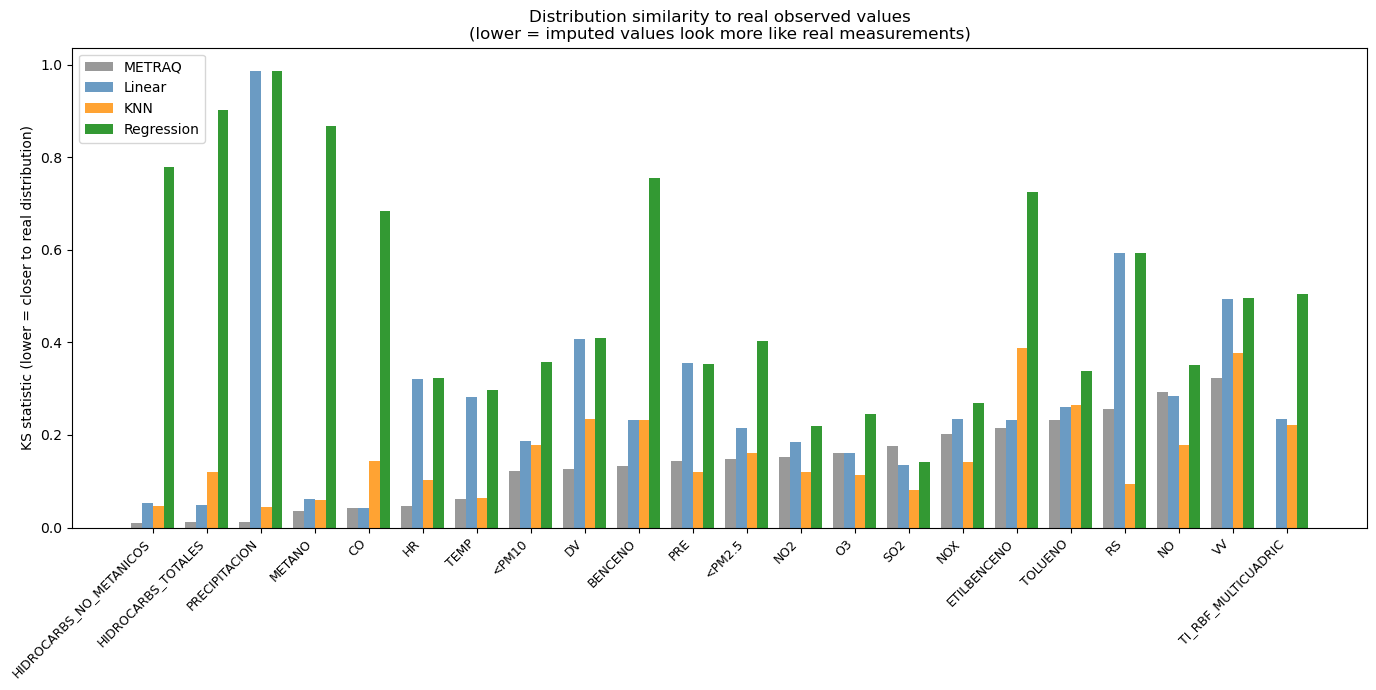

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import ks_2samp
import gc

# ── 1. Parse dates ────────────────────────────────────────────────────────────
df['entry_date'] = pd.to_datetime(df['entry_date'])

# ── 2. Extract coordinates ────────────────────────────────────────────────────
sensor_coords = df.groupby('sensor_id')[['utm_x', 'utm_y']].first()

# ── 3. Identify all rows that need imputation ─────────────────────────────────
metraq_interp_idx = df.index[df['is_interpolated']]
your_nan_idx = df.index[df['value'].isna() & ~df['is_interpolated']]
interp_idx = metraq_interp_idx.union(your_nan_idx)

print(f"METRAQ interpolated:             {len(metraq_interp_idx):,}")
print(f"Your NaNs (unreasonable values): {len(your_nan_idx):,}")
print(f"Total to impute:                 {len(interp_idx):,}")

# ── 4. Save METRAQ fills and a sample of real values ─────────────────────────
metraq_values = df.loc[metraq_interp_idx, 'value'].copy()
assert metraq_values.notna().sum() > 0, "ERROR: metraq_values is empty — restart kernel and rerun in order"

# Save max 10k real values per variable for KS test
real_values = (
    df[~df['is_interpolated']]
    .groupby('magnitude_name')['value']
    .apply(lambda s: s.dropna().sample(min(len(s.dropna()), 10000), random_state=42))
    .reset_index(level=0)
)

# ── 5. Build base missing_df with METRAQ values ───────────────────────────────
df.loc[interp_idx, 'value'] = np.nan
missing_df_base = df.loc[interp_idx, ['sensor_id', 'magnitude_name', 'entry_date']].copy()
missing_df_base['imp_metraq'] = np.nan
missing_df_base.loc[metraq_interp_idx, 'imp_metraq'] = metraq_values

# ── 6. Impute per magnitude and save to disk ──────────────────────────────────
os.makedirs('imputation_results', exist_ok=True)

for magnitude in df['magnitude_name'].unique():
    group_all = df[df['magnitude_name'] == magnitude].copy()

    # Skip if nothing to impute
    missing_idx = group_all.index[group_all['value'].isna()]
    pred_idx = missing_idx[missing_idx.isin(interp_idx)]
    if len(pred_idx) == 0:
        del group_all
        gc.collect()
        continue

    known_idx = group_all.index[group_all['value'].notna()]
    ts = group_all['entry_date']

    # Results for this magnitude only
    res = missing_df_base.loc[
        missing_df_base['magnitude_name'] == magnitude
    ].copy()

    # ── Linear interpolation ──────────────────────────────────────────────────
    interp_vals = (
        group_all.groupby('sensor_id')['value']
        .transform(lambda s: s.interpolate(method='linear'))
    )
    res['imp_linear'] = interp_vals.loc[pred_idx]
    del interp_vals

    # ── Linear regression ─────────────────────────────────────────────────────
    res['imp_regression'] = np.nan
    if len(known_idx) >= 10:
        X = pd.DataFrame({
            'hour':  ts.dt.hour,
            'dow':   ts.dt.dayofweek,
            'month': ts.dt.month,
            'year':  ts.dt.year,
            'utm_x': group_all['sensor_id'].map(sensor_coords['utm_x']),
            'utm_y': group_all['sensor_id'].map(sensor_coords['utm_y']),
        }, index=group_all.index)
        model = LinearRegression()
        model.fit(X.loc[known_idx], group_all.loc[known_idx, 'value'])
        res.loc[pred_idx, 'imp_regression'] = model.predict(X.loc[pred_idx])
        del X, model

    # ── KNN ───────────────────────────────────────────────────────────────────
    res['imp_knn'] = np.nan
    if len(known_idx) >= 5:
        X_features = pd.DataFrame({
            'hour':  ts.dt.hour,
            'dow':   ts.dt.dayofweek,
            'month': ts.dt.month,
            'year':  ts.dt.year,
            'utm_x': group_all['sensor_id'].map(sensor_coords['utm_x']),
            'utm_y': group_all['sensor_id'].map(sensor_coords['utm_y']),
        }, index=group_all.index)
        knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
        knn.fit(X_features.loc[known_idx], group_all.loc[known_idx, 'value'])
        res.loc[pred_idx, 'imp_knn'] = knn.predict(X_features.loc[pred_idx])
        del X_features, knn

    # ── Save to disk ──────────────────────────────────────────────────────────
    res.to_parquet(f'imputation_results/{magnitude}.parquet')
    print(f"Done: {magnitude} ({len(pred_idx):,} rows imputed)")

    del group_all, res
    gc.collect()

# ── 7. Load all results back ──────────────────────────────────────────────────
missing_df = pd.concat([
    pd.read_parquet(f'imputation_results/{f}')
    for f in os.listdir('imputation_results')
    if f.endswith('.parquet')
]).sort_index()

# ── 8. Fill remaining NaNs with regression as fallback ───────────────────────
missing_df['imp_linear'] = missing_df['imp_linear'].fillna(missing_df['imp_regression'])
missing_df['imp_knn']    = missing_df['imp_knn'].fillna(missing_df['imp_regression'])

gc.collect()

# ── 9. Final check ────────────────────────────────────────────────────────────
print(f"\nmissing_df shape: {missing_df.shape}")
print(f"missing_df columns: {missing_df.columns.tolist()}")
for col in ['imp_linear', 'imp_regression', 'imp_knn']:
    print(f"{col}: {missing_df[col].isna().sum():,} NaNs remaining")

# ── 10. Distribution comparison using KS test ─────────────────────────────────
methods = {
    'METRAQ':     'imp_metraq',
    'Linear':     'imp_linear',
    'Regression': 'imp_regression',
    'KNN':        'imp_knn',
}

rows = []
for magnitude in sorted(missing_df['magnitude_name'].unique()):
    real = real_values[real_values['magnitude_name'] == magnitude]['value'].dropna()
    sub  = missing_df[missing_df['magnitude_name'] == magnitude]

    if len(real) < 10:
        continue

    for label, col in methods.items():
        imputed = sub[col].dropna()
        if len(imputed) < 5:
            continue
        ks_stat, ks_pval = ks_2samp(real, imputed)
        rows.append({
            'variable': magnitude,
            'method':   label,
            'KS':       round(ks_stat, 3),
            'p_value':  round(ks_pval, 4),
            'category': categorize_magnitude(magnitude)
        })

ks_df = pd.DataFrame(rows)

print("\n=== KS statistic vs real distribution (lower = closer to real) ===")
print(ks_df.pivot(index='variable', columns='method', values='KS').to_string())

# ── 11. Best method per variable ──────────────────────────────────────────────
our_methods = ks_df[ks_df['method'] != 'METRAQ']
best = our_methods.loc[our_methods.groupby('variable')['KS'].idxmin(),
                       ['variable', 'method', 'KS', 'category']]

print("\n=== Best of our methods per variable (lowest KS) ===")
print(best.sort_values('category').to_string(index=False))

metraq_ks = ks_df[ks_df['method'] == 'METRAQ'].set_index('variable')['KS']
best_ks   = best.set_index('variable')['KS']
common    = metraq_ks.index.intersection(best_ks.index)
n_better  = (best_ks[common] < metraq_ks[common]).sum()
print(f"\nWe beat METRAQ on {n_better}/{len(common)} variables")

# ── 12. Visual comparison ─────────────────────────────────────────────────────
ks_pivot = ks_df.pivot(index='variable', columns='method', values='KS')
ks_pivot = ks_pivot.sort_values('METRAQ')

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ks_pivot))
width = 0.2
colors = ['gray', 'steelblue', 'darkorange', 'green']

for i, method in enumerate(['METRAQ', 'Linear', 'KNN', 'Regression']):
    if method in ks_pivot.columns:
        ax.bar(x + i * width, ks_pivot[method], width,
               label=method, color=colors[i], alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ks_pivot.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('KS statistic (lower = closer to real distribution)')
ax.set_title('Distribution similarity to real observed values\n(lower = imputed values look more like real measurements)')
ax.legend()
plt.tight_layout()
plt.show()

### Discussion

**Linear interpolation** works best for variables with short gaps (CO, 
HIDROCARBS) where consecutive values are similar. It completely fails on 
variables with long gaps like PRECIPITACION (KS=0.986) because it 
interpolates linearly across months of missing data producing unrealistic 
values.

**KNN** is our best overall method, winning on 9/21 variables and beating 
METRAQ on RS (0.093 vs 0.256), SO2 (0.070 vs 0.176) and NO (0.208 vs 0.292). 
It captures temporal patterns (same hour, same season) effectively without 
requiring neighboring values.

**Linear Regression** consistently produces the worst distribution similarity 
despite reasonable point estimates. This is a known weakness — regression 
predicts conditional means and collapses the variance of the distribution, 
making imputed values cluster too tightly around the mean.

**METRAQ's spatial kriging** wins overall because it uses actual measurements 
from neighboring sensors at the same timestamp — information our temporal 
methods cannot access. Our methods and METRAQ's are complementary: temporal 
methods work better when spatial neighbors are also missing, spatial methods 
work better for short gaps when neighbors are available.

## Task 4